In [8]:
import pandas as pd
import json
from pathlib import Path


dfs = []

for filepath in Path("../../results/dbscan_sample/").glob("*.json"):
    with open(filepath, "r") as f: 
        clustering_results = json.load(f)

    df = pd.DataFrame.from_dict(clustering_results, orient="index")
    df["dbcv"] = df["dbcv"].apply(lambda x: x[0])
    df["file_name"] = filepath
    
    dfs.append(df)

all_results = pd.concat(dfs, ignore_index=True)
all_results["layer"] = all_results["layer"].replace("mean", "layer_mean")

In [2]:
print(all_results.shape)
print(all_results["model"].value_counts())
print(all_results["min_samples"].value_counts())

(251, 13)
model
bert-base    146
scibert      105
Name: count, dtype: int64
min_samples
5      66
10     65
50     61
100    59
Name: count, dtype: int64


In [5]:
all_results[["model", "layer", "eps", "min_samples", "dbcv"]].sort_values("dbcv", ascending=False)

,model,layer,eps,min_samples,dbcv
170,scibert,layer_11,0.07,100,0.051028
95,bert-base,layer_12,0.13,100,0.020058
94,bert-base,layer_12,0.12,100,0.009414
200,scibert,layer_12,0.07,50,0.008310
131,bert-base,mean,0.11,50,0.008152
...,...,...,...,...,...
241,scibert,layer_mean,0.10,50,-1.000000
247,scibert,layer_mean,0.09,100,-1.000000
248,scibert,layer_mean,0.10,100,-1.000000
249,scibert,layer_mean,0.11,100,-1.000000


In [10]:
all_results[["model", "layer", "eps", "min_samples", "dbcv"]][all_results.dbcv <= -1]

,model,layer,eps,min_samples,dbcv
6,bert-base,layer_11,0.11,5,-1.0
7,bert-base,layer_11,0.12,5,-1.0
8,bert-base,layer_11,0.13,5,-1.0
9,bert-base,layer_11,0.14,5,-1.0
10,bert-base,layer_11,0.15,5,-1.0
...,...,...,...,...,...
242,scibert,layer_mean,0.11,50,-1.0
247,scibert,layer_mean,0.09,100,-1.0
248,scibert,layer_mean,0.10,100,-1.0
249,scibert,layer_mean,0.11,100,-1.0


In [3]:
print(all_results.columns)

all_results["noise_pct"] = round(all_results.n_noise / all_results.n_samples, 4) *100

Index(['model', 'layer', 'eps', 'min_samples', 'n_clusters', 'n_noise',
       'largest_cluster_size', 'largest_cluster_pct', 'runtime_seconds',
       'n_samples', 'dbcv', 'labels', 'file_name'],
      dtype='str')


In [86]:
best_performer = all_results[["model", "layer", "eps", "min_samples", "n_clusters", "noise_pct", "largest_cluster_pct", "dbcv"]].sort_values("dbcv", ascending=False).head(20)
best_performer

,model,layer,eps,min_samples,n_clusters,noise_pct,largest_cluster_pct,dbcv
170,scibert,layer_11,0.07,100,2,59.74,39.988782,0.051028
95,bert-base,layer_12,0.13,100,2,83.90,14.335223,0.020058
94,bert-base,layer_12,0.12,100,4,92.69,5.238486,0.009414
200,scibert,layer_12,0.07,50,5,95.76,1.326148,0.008310
131,bert-base,mean,0.11,50,4,73.93,17.536409,0.008152
92,bert-base,layer_12,0.10,100,3,97.88,1.213967,0.006739
79,bert-base,layer_12,0.09,50,3,98.13,1.095775,0.006715
81,bert-base,layer_12,0.11,50,5,94.12,3.848234,0.006258
189,scibert,layer_12,0.06,10,20,95.32,1.498427,0.006220
211,scibert,layer_12,0.09,100,2,87.15,9.986178,0.005964


In [85]:
print(best_performer.to_latex(
        index=False,
        column_format="llrrr",
        header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%", "DBCV"],
    ))

\begin{tabular}{llrrr}
\toprule
Model & Layer & Epsilon & MinPts & \#Cluster & Noise \% & Largest Cluster \% & DBCV \\
\midrule
scibert & layer_11 & 0.070000 & 100 & 2 & 59.740000 & 39.988782 & 0.051028 \\
bert-base & layer_12 & 0.130000 & 100 & 2 & 83.900000 & 14.335223 & 0.020058 \\
bert-base & layer_12 & 0.120000 & 100 & 4 & 92.690000 & 5.238486 & 0.009414 \\
scibert & layer_12 & 0.070000 & 50 & 5 & 95.760000 & 1.326148 & 0.008310 \\
bert-base & mean & 0.110000 & 50 & 4 & 73.930000 & 17.536409 & 0.008152 \\
bert-base & layer_12 & 0.100000 & 100 & 3 & 97.880000 & 1.213967 & 0.006739 \\
bert-base & layer_12 & 0.090000 & 50 & 3 & 98.130000 & 1.095775 & 0.006715 \\
bert-base & layer_12 & 0.110000 & 50 & 5 & 94.120000 & 3.848234 & 0.006258 \\
scibert & layer_12 & 0.060000 & 10 & 20 & 95.320000 & 1.498427 & 0.006220 \\
scibert & layer_12 & 0.090000 & 100 & 2 & 87.150000 & 9.986178 & 0.005964 \\
\bottomrule
\end{tabular}



<>:4: SyntaxWarning: invalid escape sequence '\#'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\#'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_27976/4009085109.py:4: SyntaxWarning: invalid escape sequence '\#'
  header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%", "DBCV"],
/tmp/ipykernel_27976/4009085109.py:4: SyntaxWarning: invalid escape sequence '\%'
  header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%", "DBCV"],
/tmp/ipykernel_27976/4009085109.py:4: SyntaxWarning: invalid escape sequence '\%'
  header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%", "DBCV"],


In [16]:
all_results[["model", "layer", "eps", "min_samples", "dbcv"]].sort_values(["model", "layer", "min_samples", "eps"], ascending=False).head(32)

,model,layer,eps,min_samples,dbcv
250,scibert,layer_mean,0.12,100,-1.000000
249,scibert,layer_mean,0.11,100,-1.000000
248,scibert,layer_mean,0.10,100,-1.000000
247,scibert,layer_mean,0.09,100,-1.000000
246,scibert,layer_mean,0.08,100,-0.023027
245,scibert,layer_mean,0.07,100,-0.040840
244,scibert,layer_mean,0.06,100,-0.007569
243,scibert,layer_mean,0.05,100,0.001787
242,scibert,layer_mean,0.11,50,-1.000000
241,scibert,layer_mean,0.10,50,-1.000000


In [18]:
minus_one_counts = (
    all_results
    .groupby(["eps", "min_samples"])["dbcv"]
    .apply(lambda x: (x == -1).sum())
    .reset_index(name="n_minus_one")
    .pivot(index="eps", columns="min_samples", values="n_minus_one")
    .reset_index()
)

minus_one_counts

min_samples,eps,5,10,50,100
0,0.02,0.0,0.0,NaN,NaN
1,0.03,0.0,0.0,NaN,NaN
2,0.04,0.0,0.0,0.0,NaN
3,0.05,0.0,0.0,0.0,0.0
4,0.06,0.0,0.0,0.0,0.0
5,0.07,1.0,1.0,2.0,0.0
6,0.08,2.0,2.0,2.0,2.0
7,0.09,1.0,1.0,2.0,3.0
8,0.10,1.0,2.0,3.0,3.0
9,0.11,3.0,3.0,3.0,2.0


In [19]:
cluster_counts = (
    all_results
    .groupby(["eps", "min_samples"])
    .size()
    .unstack("min_samples")
)

cluster_counts

min_samples,5,10,50,100
eps,,,,
0.02,2.0,1.0,NaN,NaN
0.03,3.0,2.0,NaN,NaN
0.04,4.0,3.0,2.0,NaN
0.05,6.0,4.0,2.0,2.0
0.06,6.0,6.0,3.0,2.0
0.07,6.0,6.0,5.0,3.0
0.08,6.0,6.0,6.0,5.0
0.09,5.0,5.0,6.0,6.0
0.10,4.0,5.0,6.0,6.0


In [22]:
minus_one_pct = (
    all_results
    .groupby(["eps", "min_samples"])["dbcv"]
    .apply(lambda x: (x == -1).mean() * 100)
    .unstack("min_samples")
)

#minus_one_pct
minus_one_pct.style.format("{:.1f}")

min_samples,5,10,50,100
eps,,,,
0.020000,0.0,0.0,nan,nan
0.030000,0.0,0.0,nan,nan
0.040000,0.0,0.0,0.0,nan
0.050000,0.0,0.0,0.0,0.0
0.060000,0.0,0.0,0.0,0.0
0.070000,16.7,16.7,40.0,0.0
0.080000,33.3,33.3,33.3,40.0
0.090000,20.0,20.0,33.3,50.0
0.100000,25.0,40.0,50.0,50.0


In [28]:
import numpy as np

plot_results = all_results.copy()

plot_results.loc[plot_results["dbcv"] == -1, "dbcv"] = np.nan

plot_results["layer"] = plot_results["layer"].replace("mean", "layer_mean")

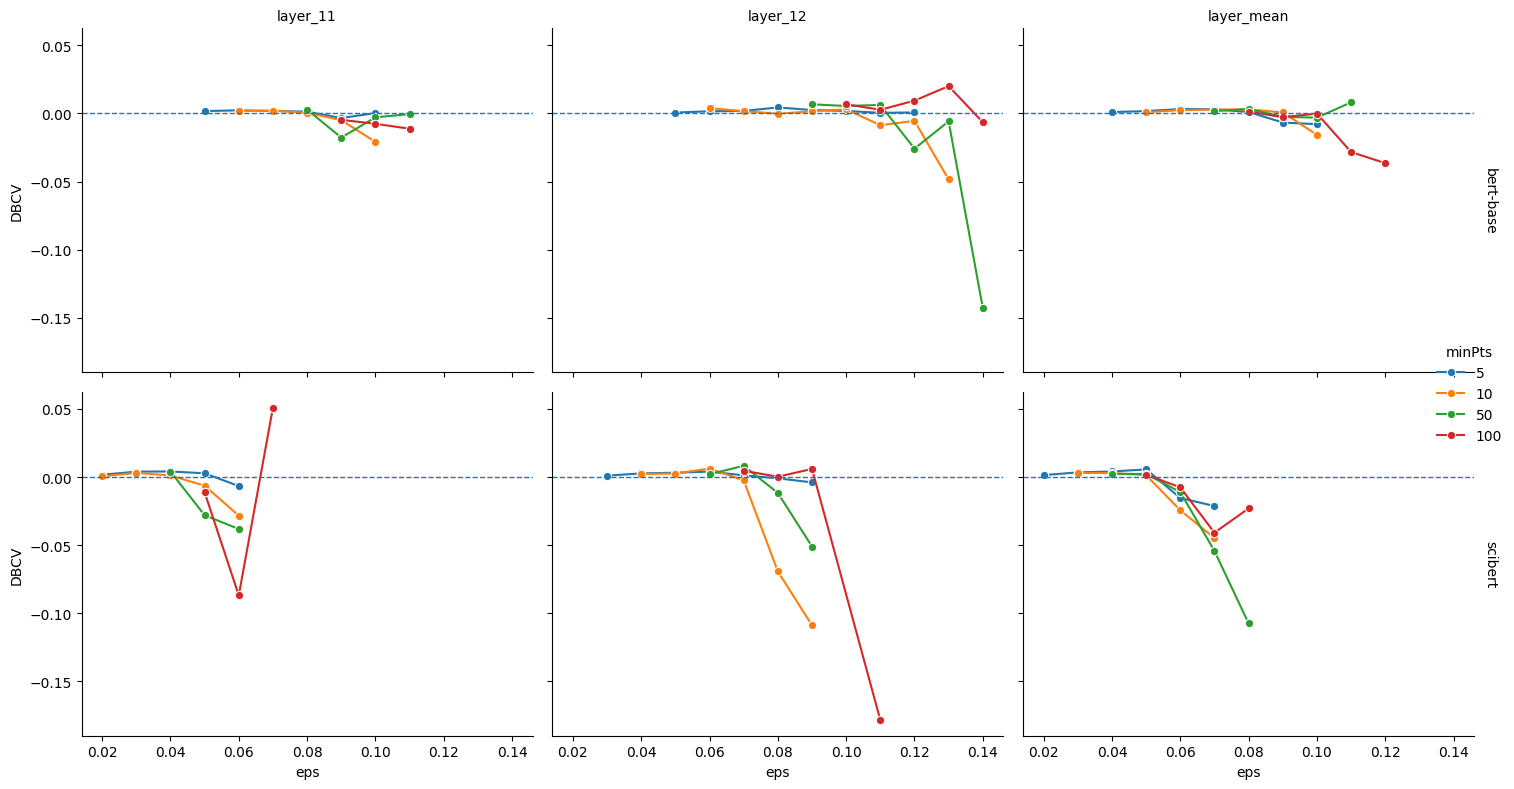

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    plot_results,
    row="model",
    col="layer",
    hue="min_samples",
    height=4,
    aspect=1.2,
    margin_titles=True,
    palette="tab10"
)

g.map_dataframe(
    sns.lineplot,
    x="eps",
    y="dbcv",
    marker="o"
)

g.add_legend(title="minPts")

# Add DBCV = 0 reference line to every facet
for ax in g.axes.flat:
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("eps")
    ax.set_ylabel("DBCV")

g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()

/tmp/ipykernel_122823/1933122687.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  model: (cm.get_cmap("Greens") if model == "scibert" else cm.get_cmap("Blues"))
/tmp/ipykernel_122823/1933122687.py:112: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  gray_cmap = cm.get_cmap("Greys")


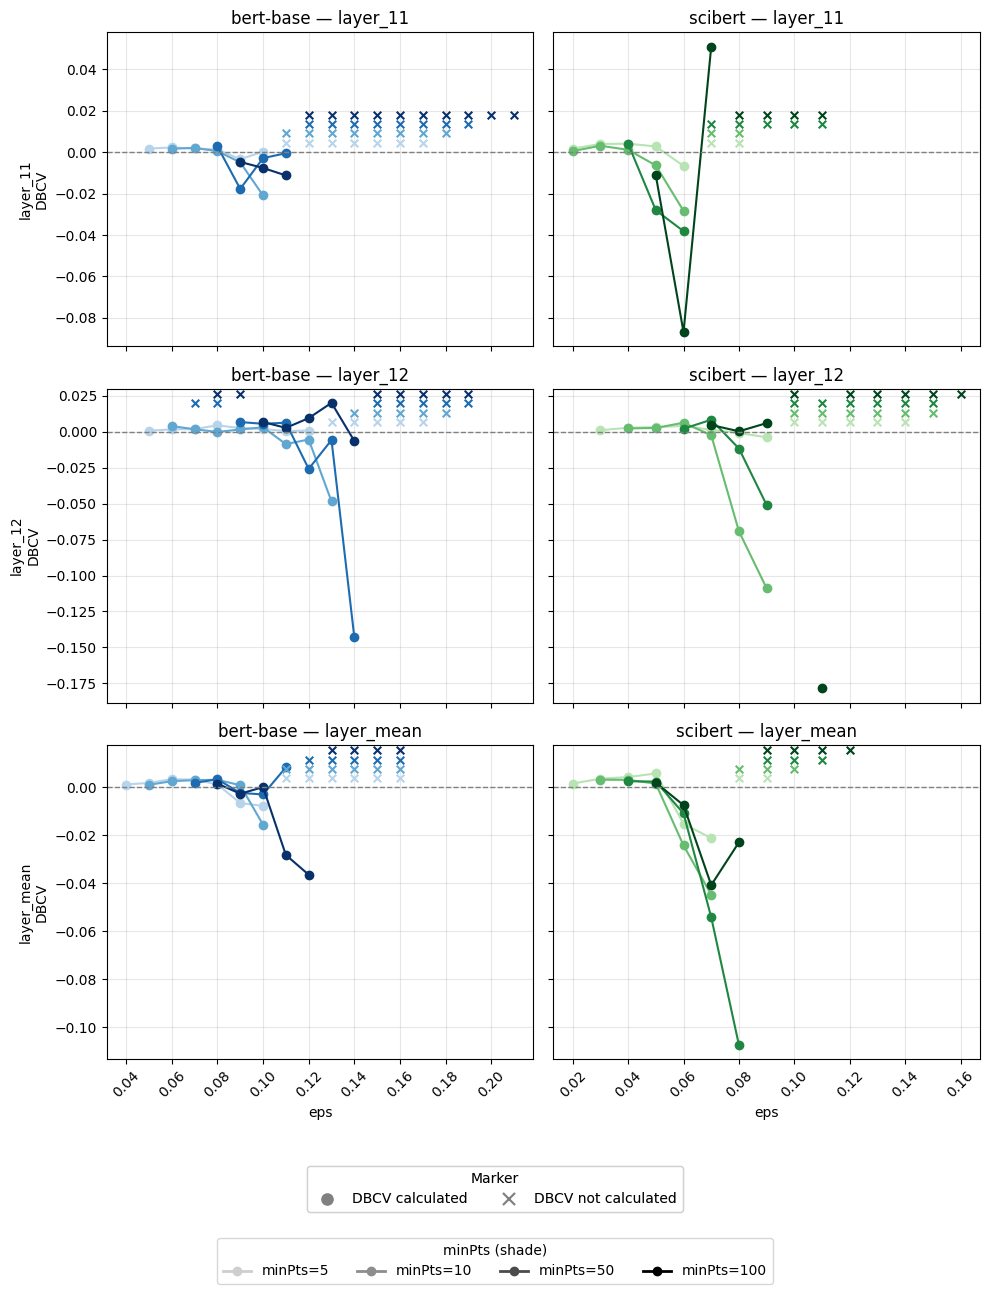

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
#import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker



plot_results = all_results.copy()
plot_results["layer"] = plot_results["layer"].replace("mean", "layer_mean")
plot_results.loc[plot_results["dbcv"] == -1, "dbcv"] = np.nan

models = sorted(plot_results["model"].unique())
layers = sorted(plot_results["layer"].unique())
minpts_values = sorted(plot_results["min_samples"].unique())

n_rows, n_cols = len(layers), len(models)
combos = [(layer, model) for layer in layers for model in models]

# --- color: single hue, tone by minPts (lighter = smaller minPts) ---
cmap_by_model = {
    model: (cm.get_cmap("Greens") if model == "scibert" else cm.get_cmap("Blues"))
    for model in models
}

lo, hi = 0.3, 1
n = len(minpts_values)
positions = [hi] if n == 1 else np.linspace(lo, hi, n)
sorted_minpts = sorted(minpts_values)

# palette is now per (model, minpts)
palette = {
    (model, mp): cmap_by_model[model](pos)
    for model in models
    for mp, pos in zip(sorted_minpts, positions)
}

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows),
    sharex="col", sharey="row"
)
axes = np.atleast_2d(axes).reshape(n_rows, n_cols)
axes_flat = axes.flatten()

for ax, (layer, model) in zip(axes_flat, combos):
    subset = plot_results[
        (plot_results["model"] == model) & (plot_results["layer"] == layer)
    ]

    for minpts in minpts_values:
        data = subset[subset["min_samples"] == minpts].sort_values("eps")
        ax.plot(
            data["eps"], data["dbcv"],
            marker="o", label=f"minPts={minpts}", color=palette[(model, minpts)]
        )

    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.02))
    ax.tick_params(axis="x", labelrotation=45)

    ax.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{model} — {layer}")

# row/col labels only on edges
for i, layer in enumerate(layers):
    axes[i, 0].set_ylabel(f"{layer}\nDBCV")
for j in range(n_cols):
    axes[-1, j].set_xlabel("eps")

fig.canvas.draw()

for i in range(n_rows):
    row_axes = axes[i, :]
    ymin, ymax = row_axes[0].get_ylim()
    step = (ymax - ymin) * 0.03
    max_stack_height = step * len(minpts_values)

    # make sure the stacked X's actually fit within the row's y-range
    if ymax < max_stack_height:
        ymax = max_stack_height * 1.15  # small padding above the top marker

    for j in range(n_cols):
        ax = row_axes[j]
        layer, model = combos[i * n_cols + j]
        for k, minpts in enumerate(minpts_values):
            missing = all_results[
                (all_results["model"] == model) &
                (all_results["layer"] == layer) &
                (all_results["min_samples"] == minpts) &
                (all_results["dbcv"] == -1)
            ]
            y_pos = step * (k + 1)
            for eps in missing["eps"].unique():
                ax.scatter(
                    eps, y_pos,
                    marker="x", s=30, color=palette[(model, minpts)],
                    linewidths=1.5, zorder=5
                )

    for ax in row_axes:
        ax.set_ylim(ymin, ymax)

        
# Legend 1: hue = model
model_handles = [
    Line2D([0], [0], color=cmap_by_model[model](0.8), lw=2, label=model)
    for model in models
]

# Legend 2: tone = minPts (rendered in gray so it reads as "lightness", not a specific model)
gray_cmap = cm.get_cmap("Greys")
minpts_handles = [
    Line2D([0], [0], color=gray_cmap(pos), lw=2, marker="o", label=f"minPts={mp}")
    for mp, pos in zip(sorted_minpts, positions)
]
marker_handles = [
    Line2D([0], [0], marker="o", color="gray", linestyle="None",
           markersize=8, label="DBCV calculated"),
    Line2D([0], [0], marker="x", color="gray", linestyle="None",
           markersize=8, markeredgewidth=1.5, label="DBCV not calculated"),
]

legend1 = fig.legend(
    handles=marker_handles, title="Marker",
    loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2
)
legend2 = fig.legend(
    handles=minpts_handles, title="minPts (shade)",
    loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=len(sorted_minpts)
)
fig.add_artist(legend1)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave room at the bottom for the legend
plt.show()

# any clusters in the schubert et al., 2017 range?

In [7]:
all_results[["model", "layer", "eps", "min_samples", "n_clusters", "noise_pct", "largest_cluster_pct", "dbcv"]][(all_results.model == "bert-base") & (all_results.layer == "mean")]

,model,layer,eps,min_samples,n_clusters,noise_pct,largest_cluster_pct,dbcv
102,bert-base,mean,0.04,5,14,99.72,0.058094,0.001029
103,bert-base,mean,0.05,5,26,99.23,0.172279,0.001712
104,bert-base,mean,0.06,5,47,97.87,0.783269,0.003261
105,bert-base,mean,0.07,5,79,95.34,1.534486,0.003064
106,bert-base,mean,0.08,5,79,90.62,5.546986,0.001060
107,bert-base,mean,0.09,5,117,81.77,10.262625,-0.006677
108,bert-base,mean,0.10,5,91,67.66,19.235161,-0.007881
109,bert-base,mean,0.11,5,47,50.37,47.869549,-1.000000
110,bert-base,mean,0.12,5,28,34.23,65.351870,-1.000000
111,bert-base,mean,0.13,5,18,21.64,78.146597,-1.000000


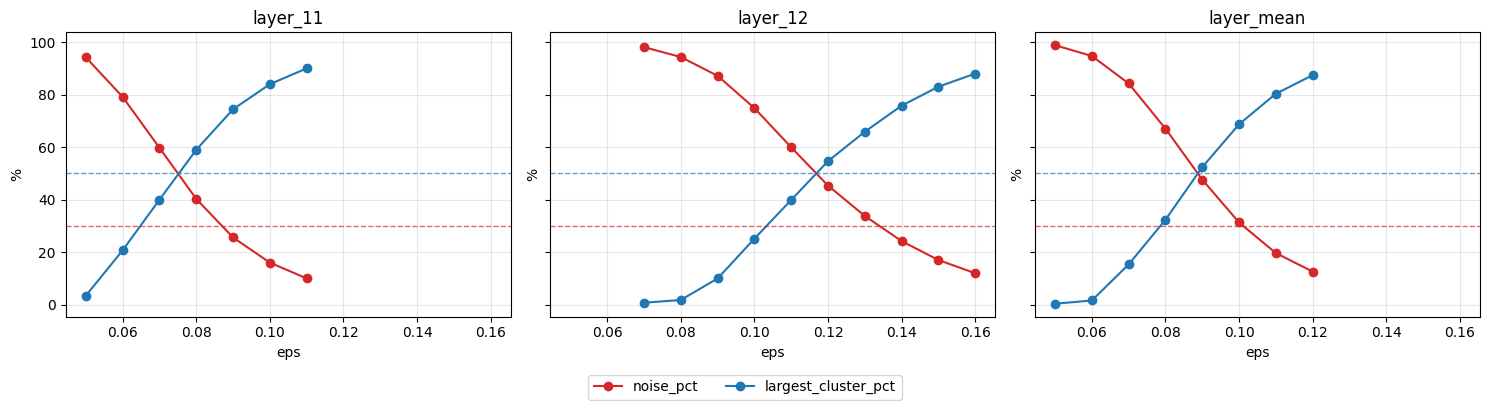

In [92]:
import numpy as np
import matplotlib.pyplot as plt

subset = all_results[
    (all_results["model"] == "scibert") & (all_results["min_samples"] == 100)
].copy()
subset["layer"] = subset["layer"].replace("mean", "layer_mean")

layers = sorted(subset["layer"].unique())
n_cols = 3
n_rows = int(np.ceil(len(layers) / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows),
    sharex=True, sharey=True
)
axes = np.atleast_1d(axes).flatten()

for ax, layer in zip(axes, layers):
    data = subset[subset["layer"] == layer].sort_values("eps")

    ax.plot(data["eps"], data["noise_pct"], marker="o", color="tab:red", label="noise_pct")
    ax.plot(data["eps"], data["largest_cluster_pct"], marker="o", color="tab:blue", label="largest_cluster_pct")

    ax.axhline(50, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(30, color="tab:red", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(layer)
    ax.set_xlabel("eps")
    ax.set_ylabel("%")
    ax.grid(True, alpha=0.3)

# turn off any unused axes
for ax in axes[len(layers):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

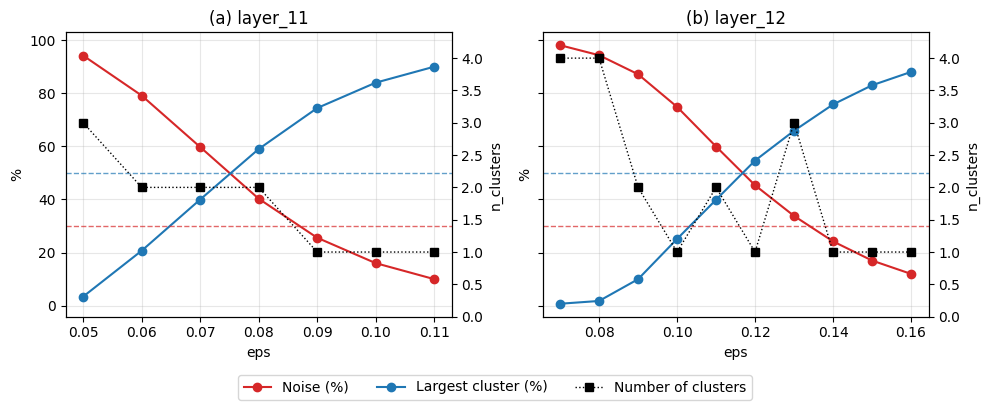

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import string

subset = all_results[
    (all_results["model"] == "scibert") & (all_results["min_samples"] == 100) & ~(all_results["layer"] == "layer_mean")
].copy()
subset["layer"] = subset["layer"].replace("mean", "layer_mean")

layers = sorted(subset["layer"].unique())
n_cols = 2
n_rows = int(np.ceil(len(layers) / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows),
    sharex=False, sharey=True
)
axes = np.atleast_1d(axes).flatten()

twin_axes = []

for i, (ax, layer) in enumerate(zip(axes, layers)):
    data = subset[subset["layer"] == layer].sort_values("eps")
    panel_label = string.ascii_lowercase[i]  # a, b, c, ...

    ax.plot(data["eps"], data["noise_pct"], marker="o", color="tab:red", label="Noise (%)")
    ax.plot(data["eps"], data["largest_cluster_pct"], marker="o", color="tab:blue", label="Largest cluster (%)")

    ax.axhline(50, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(30, color="tab:red", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(f"({panel_label}) {layer}")
    ax.set_xlabel("eps")
    ax.set_ylabel("%")
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(
        data["eps"], data["n_clusters"],
        marker="s", color="black", linestyle=":", linewidth=1, label="Number of clusters"
    )
    ax2.set_ylabel("n_clusters")
    twin_axes.append(ax2)

# turn off any unused axes
for ax in axes[len(layers):]:
    ax.axis("off")

# share n_clusters y-axis across all twin axes so counts are comparable
if twin_axes:
    max_clusters = subset["n_clusters"].max()
    for ax2 in twin_axes:
        ax2.set_ylim(0, max_clusters * 1.1)

# combine legend entries from the main axis and its twin
h1, l1 = axes[0].get_legend_handles_labels()
h2, l2 = twin_axes[0].get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=3)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

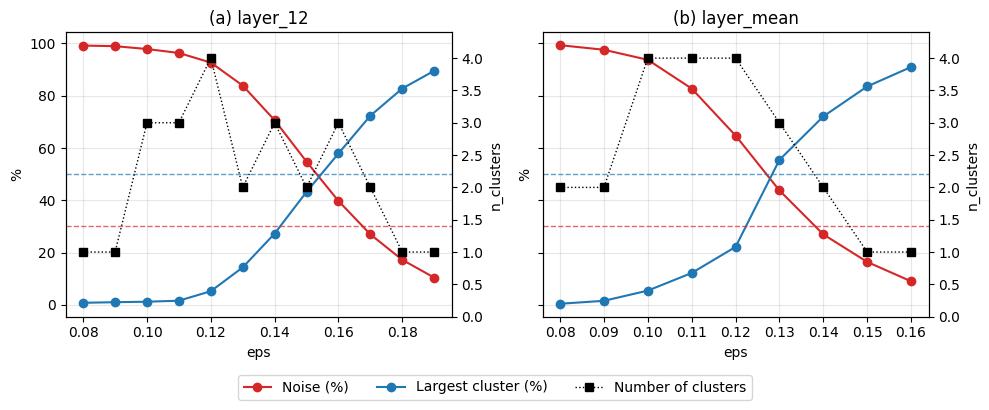

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import string


subset = all_results[
    (all_results["model"] == "bert-base") & (all_results["min_samples"] == 100) & ~(all_results["layer"] == "layer_11")
].copy()
subset["layer"] = subset["layer"].replace("mean", "layer_mean")

layers = sorted(subset["layer"].unique())
n_cols = 2
n_rows = int(np.ceil(len(layers) / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows),
    sharex=False, sharey=True
)
axes = np.atleast_1d(axes).flatten()

twin_axes = []  # keep references so we can share/format them after the loop

for i, (ax, layer) in enumerate(zip(axes, layers)):
    data = subset[subset["layer"] == layer].sort_values("eps")
    panel_label = string.ascii_lowercase[i]  # a, b, c, ...

    ax.plot(data["eps"], data["noise_pct"], marker="o", color="tab:red", label="Noise (%)")
    ax.plot(data["eps"], data["largest_cluster_pct"], marker="o", color="tab:blue", label="Largest cluster (%)")

    ax.axhline(50, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(30, color="tab:red", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(f"({panel_label}) {layer}")
    ax.set_xlabel("eps")
    ax.set_ylabel("%")
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(
        data["eps"], data["n_clusters"],
        marker="s", color="black", linestyle=":", linewidth=1, label="Number of clusters"
    )
    ax2.set_ylabel("n_clusters")
    twin_axes.append(ax2)

# turn off any unused axes
for ax in axes[len(layers):]:
    ax.axis("off")

# share n_clusters y-axis across all twin axes so counts are comparable
if twin_axes:
    max_clusters = subset["n_clusters"].max()
    for ax2 in twin_axes:
        ax2.set_ylim(0, max_clusters * 1.1)

# combine legend entries from the main axis and its twin
h1, l1 = axes[0].get_legend_handles_labels()
h2, l2 = twin_axes[0].get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=3)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()